# TF-IDF Word Clouds — Manual Implementation

**TF-IDF approach:** week8-style — tokens are pooled per community/party group, TF is computed on the pooled bag, IDF uses smoothed sklearn-style formula: `log(N / (1 + df)) + 1`.

**Wordcloud palette:** `plasma` colormap matching week8 style.

In [1]:
import pandas as pd
import numpy as np
import ast
import re
from collections import Counter, defaultdict
from wordcloud import WordCloud
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 120})

text_df = pd.read_csv("tokenized_wikipage2.csv")

## 1 — Parse tokens & build stopwords

In [2]:
def safe_parse(val):
    if not isinstance(val, str): return []
    try:    return ast.literal_eval(val)
    except: return val.split()

text_df["tokens_parsed"] = text_df["tokens_lemmatized"].apply(safe_parse)

# ── Auto-generate name stopwords from the dataset ─────────────────────────────
name_stopwords = set()
for name in text_df["name"].dropna():
    parts = re.sub(r"[^a-zA-Z ]", "", name.lower()).split()
    name_stopwords.update(parts)
print(f"Name-derived stopwords: {len(name_stopwords)}")

# ── Geographic terms that dominate geo-heavy communities ──────────────────────
GEO_STOPWORDS = {
    "california", "los", "angeles", "san", "francisco", "diego",
    "jose", "sacramento", "fresno", "riverside", "oakland",
    "york", "manhattan", "brooklyn", "bronx", "queens", "albany",
    "buffalo", "harlem", "staten", "island",
    "jersey", "newark", "camden", "bergen", "essex", "passaic",
    "hunterdon", "rutgers",
    "alaska", "hawaii", "anchorage", "fairbanks", "honolulu",
    "albuquerque", "pacific", "hawaiian", "alaskan",
    "city", "county", "township", "borough",
    "municipality", "region", "area", "neighborhood",
    "north", "south", "east", "west", "central",
}

# ── Wikipedia boilerplate + generic political terms ───────────────────────────
BOILERPLATE = {
    "born", "die", "death", "age", "old", "year", "serve", "serving",
    "served", "also", "one", "two", "three", "first", "second", "third",
    "new", "later", "early", "late", "since", "become", "include",
    "many", "well", "make", "take", "give", "come", "go", "know",
    "time", "way", "part", "day", "use", "say", "would", "could",
    "th", "u", "s", "d", "r", "man", "woman",
    "american", "united", "state", "states", "federal",
    "political", "politician", "politics",
    "member", "congress", "congressional",
    "representative", "senator", "president", "vice",
    "democrat", "republican", "democratic", "party",
    "election", "elect", "elected", "reelect",
    "office", "term", "campaign", "vote", "voting",
    "government", "administration", "official",
    "house", "senate", "committee", "bill", "law",
    "national", "public", "support", "oppose",
    "position", "issue", "school", "university",
    "work", "primary", "general", "local", "special",
    "district", "mayor", "governor", "assembly", "council", "attorney",
    "delegate", "secretary", "treasurer", "commissioner", "legislature",
    "legislative", "executive", "judicial", "statehouse", "capitol",
    "subcommittee", "speaker", "chairman", "chairwoman", "chairperson",
    "leader", "leaders", "caucus", "kansa", "lieutenant", "court",
    "alabama", "arizona", "arkansas", "colorado", "connecticut",
    "delaware", "florida", "georgia", "idaho", "illinois", "indiana",
    "iowa", "kansas", "kentucky", "louisiana", "maine", "maryland",
    "massachusetts", "michigan", "minnesota", "mississippi", "missouri",
    "montana", "nebraska", "nevada", "hampshire", "mexico", "carolina",
    "dakota", "ohio", "oklahoma", "oregon", "pennsylvania", "rhode",
    "tennessee", "texas", "utah", "vermont", "virginia", "washington",
    "wisconsin", "wyoming", "chicago", "cincinnati", "columbus", "cleveland",
    "detroit", "miami", "atlanta", "boston", "memphis", "nashville",
    "knoxville", "louisville", "lexington", "richmond", "norfolk",
    "portland", "salem", "eugene", "houston", "dallas", "austin",
    "antonio", "el", "paso",
}

STOPWORDS = name_stopwords | GEO_STOPWORDS | BOILERPLATE
print(f"Total stopwords: {len(STOPWORDS)}")

# ── Filter tokens ──────────────────────────────────────────────────────────────
def filter_tokens(token_list):
    return [
        t for t in token_list
        if len(t) >= 3
        and not t.isdigit()
        and not re.match(r'^\d', t)
        and t not in STOPWORDS
        and re.match(r'^[a-z]', t)
    ]

text_df["tokens_filtered"] = text_df["tokens_parsed"].apply(filter_tokens)
text_df["doc_len"]         = text_df["tokens_filtered"].str.len()

df_valid = text_df[text_df["doc_len"] >= 30].copy().reset_index(drop=True)
print(f"Valid documents : {len(df_valid)}")
print(f"Mean doc length : {df_valid['doc_len'].mean():.0f} tokens")
print(f"Median          : {df_valid['doc_len'].median():.0f} tokens")

sample = df_valid[df_valid["doc_len"] > 100].iloc[0]
print(f"\nSample ({sample['name']}): {sample['tokens_filtered'][:20]}")

Name-derived stopwords: 5314
Total stopwords: 5530
Valid documents : 5715
Mean doc length : 498 tokens
Median          : 256 tokens

Sample (Stephen Miller): ['advisor', 'deputy', 'chief', 'staff', 'policy', 'homeland', 'security', 'advisor', 'senior', 'advisor', 'director', 'speechwriting', 'considered', 'influential', 'figure', 'trumpism', 'movement', 'describe', 'farright', 'antiimmigration']


## 2 — TF-IDF (week8-style: pool tokens per group)

**TF** is computed on the pooled token bag for the entire group (party or community):
$$TF(t, g) = \log\left(1 + \frac{\text{count}(t, g)}{|g|}\right)$$

**IDF** is computed across all communities/parties using the smoothed sklearn formula:
$$IDF(t) = \log\left(\frac{N}{1 + df(t)}\right) + 1$$

This prevents division by zero and ensures terms in every group get IDF=1 rather than 0.

In [3]:
def compute_tf_pooled(token_list):
    """TF on a pooled bag of tokens for an entire group (week8 style)."""
    n = len(token_list)
    if n == 0:
        return {}
    counts = Counter(token_list)
    return {term: np.log(1 + count / n) for term, count in counts.items()}


def compute_idf_smoothed(groups_tokens, N):
    """
    Smoothed IDF (sklearn-style): log(N / (1 + df)) + 1
    groups_tokens: list of token lists, one per group
    N: total number of groups
    """
    doc_freq = defaultdict(int)
    for token_list in groups_tokens:
        for term in set(token_list):
            doc_freq[term] += 1
    return {
        term: np.log(N / (1 + df)) + 1
        for term, df in doc_freq.items()
    }


def group_tfidf_pooled(token_list, idf_dict, top_n=80):
    """
    Compute TF on pooled token_list, multiply by IDF, return top_n terms.
    """
    tf = compute_tf_pooled(token_list)
    tfidf = {
        term: tf_val * idf_dict.get(term, 0)
        for term, tf_val in tf.items()
        if idf_dict.get(term, 0) > 0
    }
    return dict(sorted(tfidf.items(), key=lambda x: x[1], reverse=True)[:top_n])

## 3 — Party word clouds

In [4]:
PARTY_COLORS = {"Democrat": "#2166ac", "Republican": "#d6604d"}
parties = ["Democrat", "Republican"]

# Pool tokens per party
party_token_pools = {
    p: df_valid[df_valid["party"] == p]["tokens_filtered"].explode().tolist()
    for p in parties
}

# IDF across the two party groups
N_parties   = len(parties)
party_idf   = compute_idf_smoothed(list(party_token_pools.values()), N_parties)

# TF-IDF per party
party_terms = {
    p: group_tfidf_pooled(party_token_pools[p], party_idf)
    for p in parties
}

for party, terms in party_terms.items():
    print(f"\n{party} top 10 terms:")
    for term, score in list(terms.items())[:10]:
        print(f"  {term:30s}  {score:.5f}")


Democrat top 10 terms:
  run                             0.00353
  act                             0.00289
  defeat                          0.00237
  january                         0.00227
  life                            0.00227
  education                       0.00226
  former                          0.00225
  november                        0.00207
  receive                         0.00207
  announce                        0.00207

Republican top 10 terms:
  run                             0.00328
  act                             0.00310
  defeat                          0.00250
  january                         0.00245
  former                          0.00238
  call                            0.00215
  life                            0.00212
  receive                         0.00205
  november                        0.00201
  announce                        0.00195


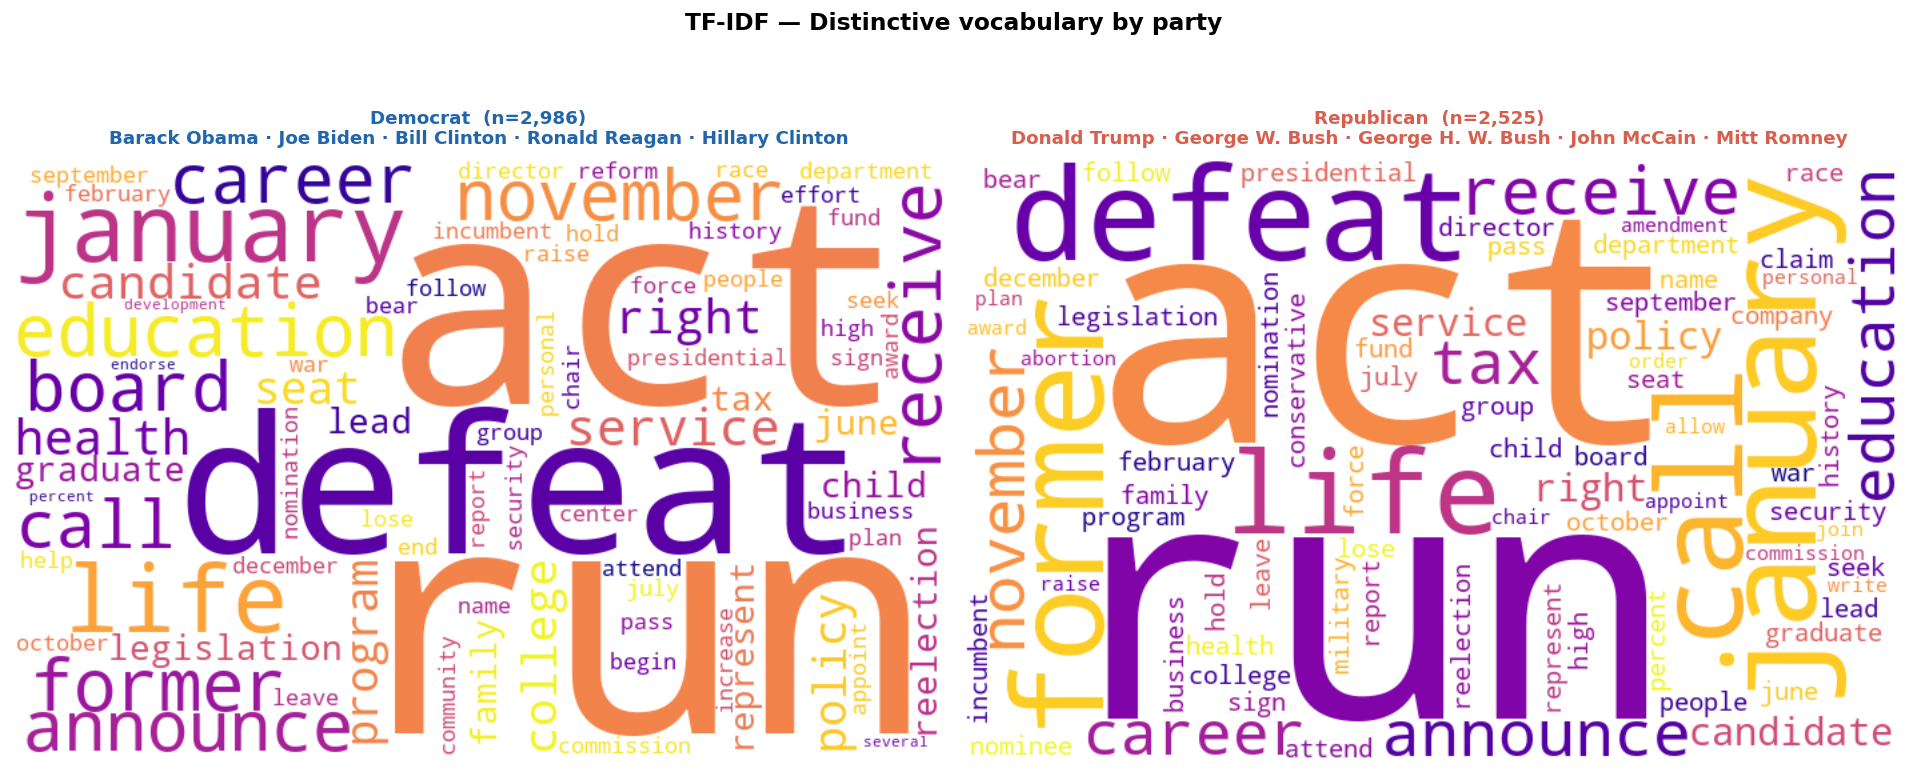

Saved → tfidf_party.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, (party, terms) in zip(axes, party_terms.items()):
    n    = len(df_valid[df_valid["party"] == party])
    top5 = (df_valid[df_valid["party"] == party]
            .dropna(subset=["degree"])
            .nlargest(5, "degree")["name"].tolist())

    wc = WordCloud(
        width=700, height=450,
        background_color="white",
        colormap="plasma",          # week8 palette
        contour_width=1,
        contour_color="black",
        max_words=200,
        prefer_horizontal=0.85,
        min_font_size=9,
        collocations=False,
    ).generate_from_frequencies(terms)

    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(
        f"{party}  (n={n:,})\n" + " · ".join(top5),
        fontsize=11, fontweight="bold", pad=10,
        color=PARTY_COLORS[party],
    )
    ax.axis("off")

plt.suptitle("TF-IDF — Distinctive vocabulary by party",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("tfidf_party.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → tfidf_party.png")

## 4 — Community word clouds

In [6]:
community_sizes = df_valid["community"].value_counts()
top_communities = community_sizes[community_sizes >= 50].head(9).index.tolist()

# Pool tokens per community
comm_token_pools = {
    cid: df_valid[df_valid["community"] == cid]["tokens_filtered"].explode().tolist()
    for cid in top_communities
}

# IDF across top communities
N_comms  = len(top_communities)
comm_idf = compute_idf_smoothed(list(comm_token_pools.values()), N_comms)

# TF-IDF per community
print("Computing community TF-IDF...")
comm_terms = {}
for cid in top_communities:
    comm_terms[cid] = group_tfidf_pooled(comm_token_pools[cid], comm_idf)
    top5 = list(comm_terms[cid].keys())[:5]
    print(f"  Community {int(cid):3d} (n={int(community_sizes[cid]):4d}): {top5}")

Computing community TF-IDF...
  Community  15 (n= 777): ['act', 'presidential', 'run', 'former', 'war']
  Community   2 (n= 646): ['act', 'run', 'call', 'january', 'announce']
  Community   5 (n= 615): ['act', 'run', 'january', 'call', 'defeat']
  Community  30 (n= 353): ['run', 'board', 'act', 'life', 'defeat']
  Community   6 (n= 254): ['run', 'former', 'november', 'act', 'announce']
  Community   7 (n= 242): ['run', 'defeat', 'act', 'january', 'seat']
  Community  22 (n= 237): ['run', 'board', 'tax', 'act', 'announce']
  Community  19 (n= 174): ['run', 'act', 'former', 'defeat', 'november']
  Community  16 (n= 172): ['run', 'defeat', 'seat', 'january', 'former']


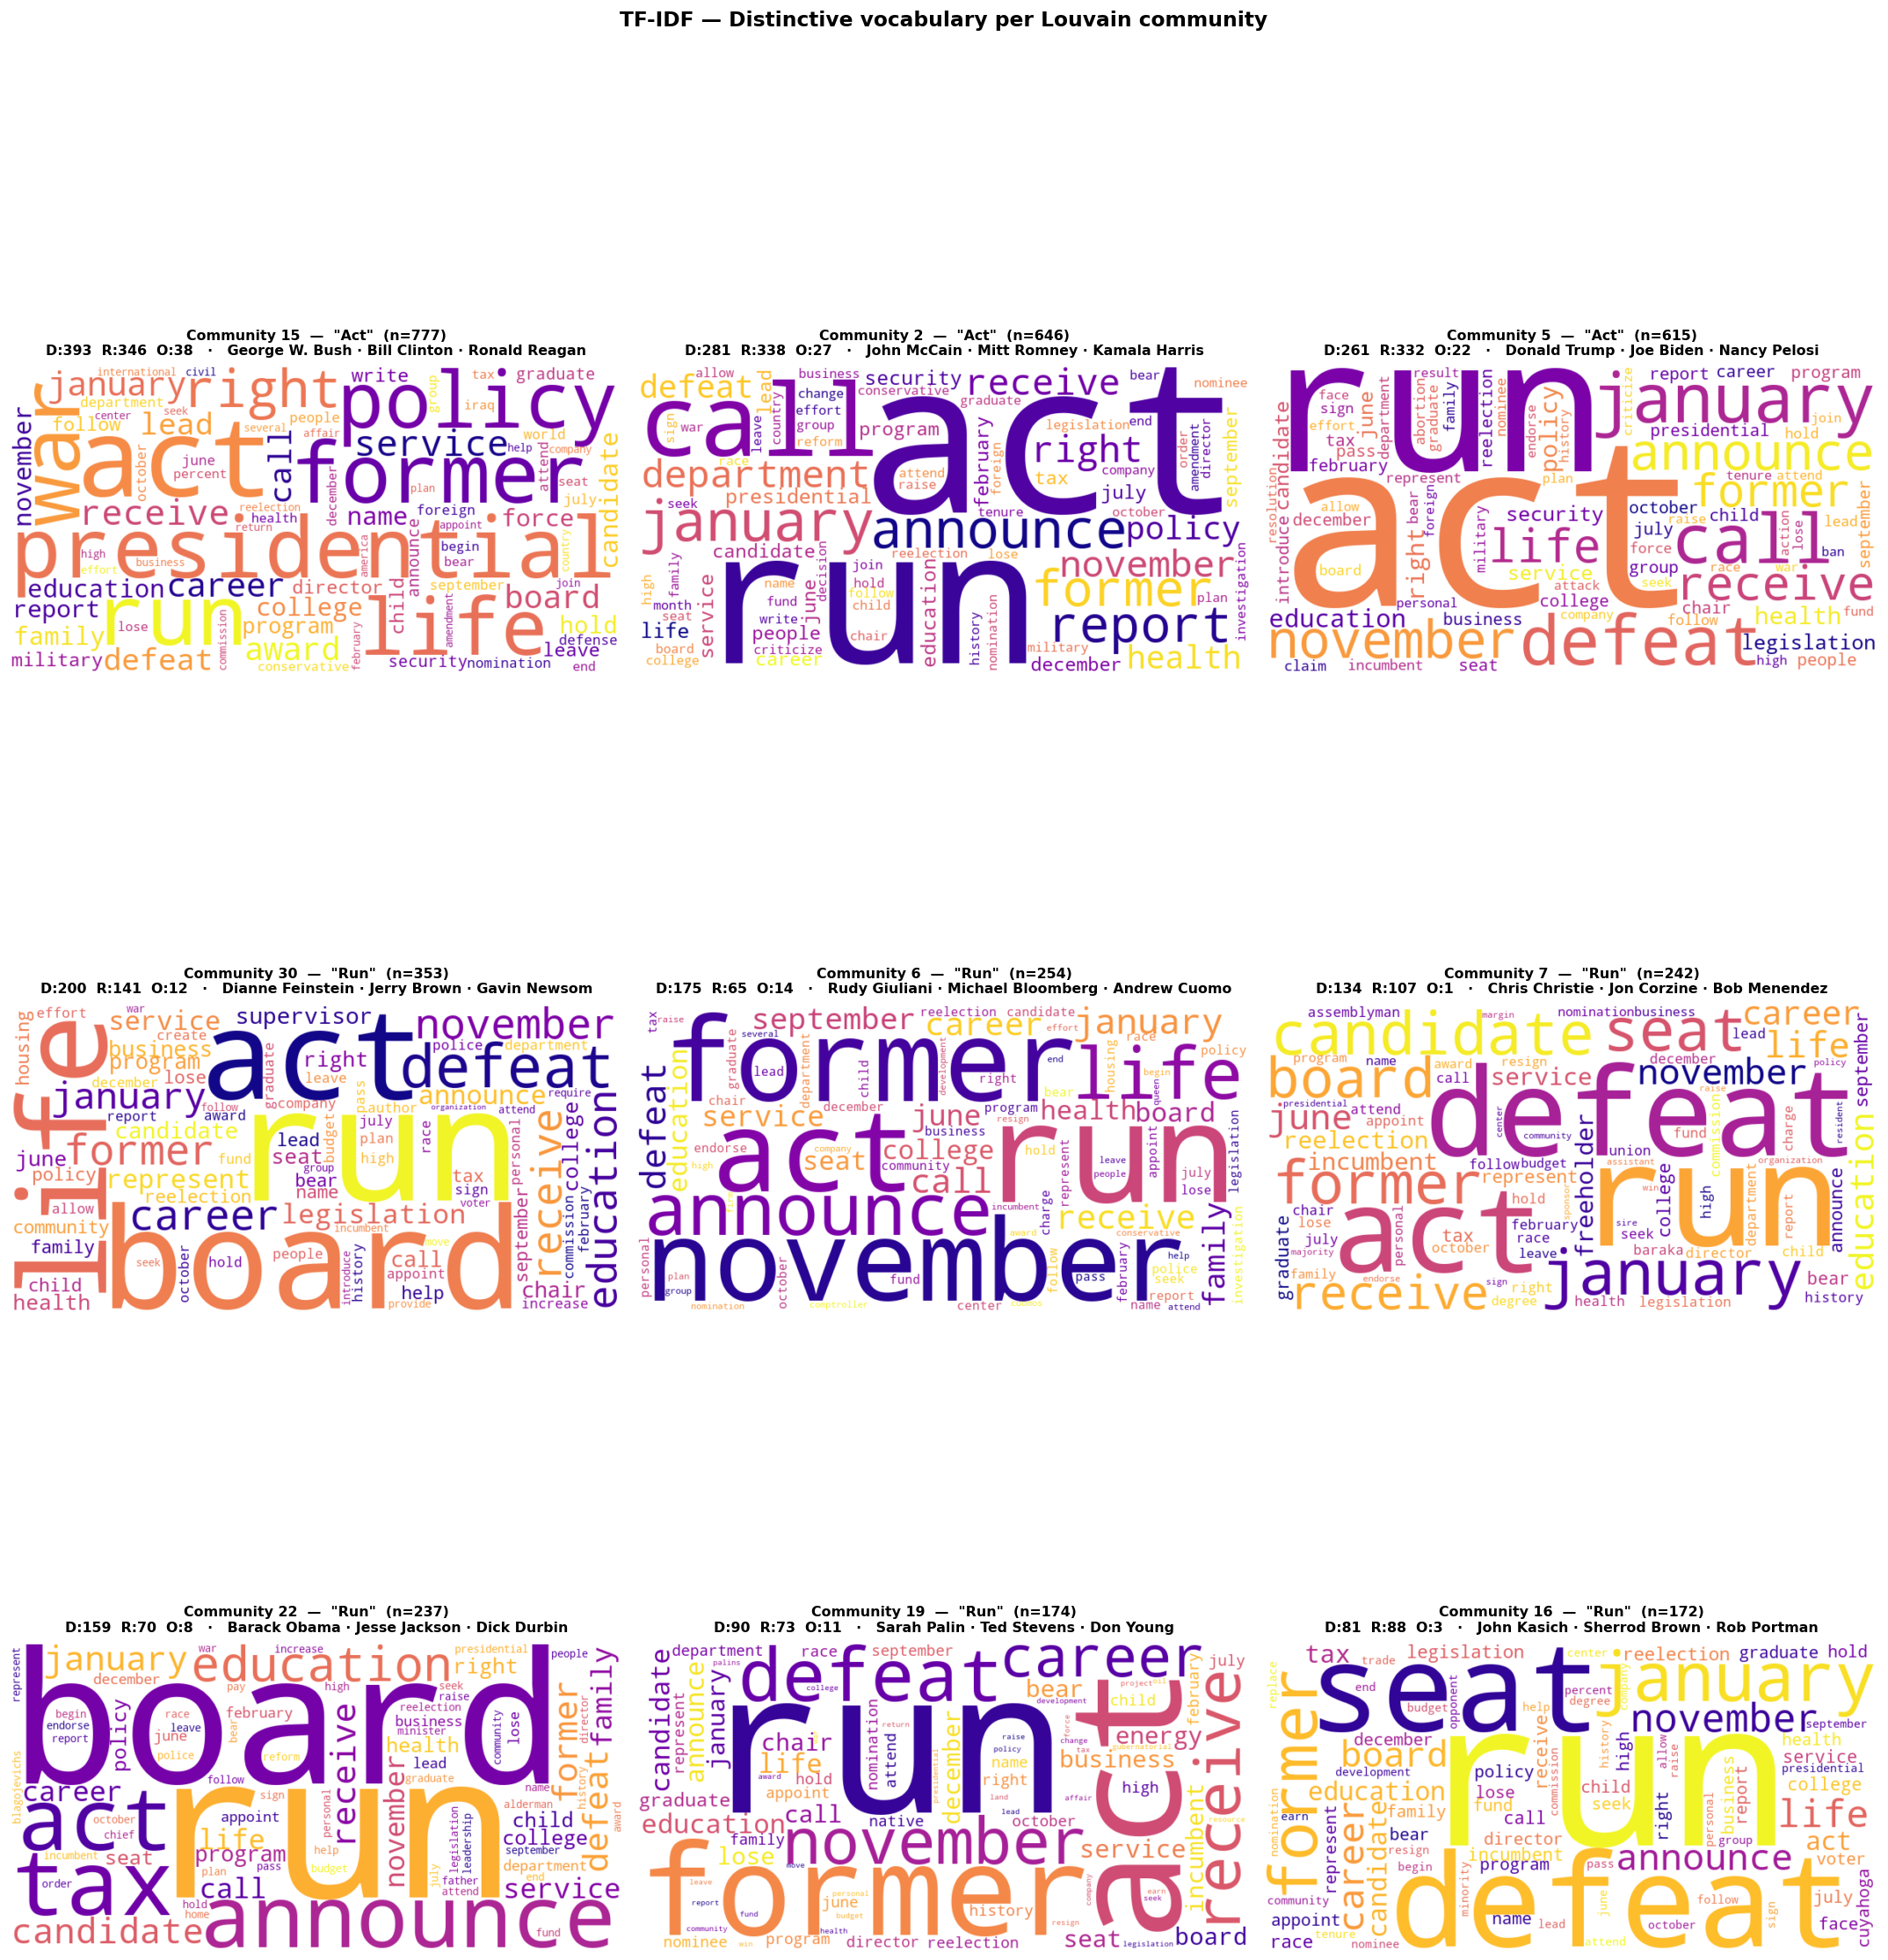

Saved → tfidf_communities.png


In [7]:
n_cols = 3
n_rows = (len(top_communities) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols,
                          figsize=(18, 7 * n_rows), facecolor="white")
axes_flat = list(axes.flat)

for i, (ax, cid) in enumerate(zip(axes_flat, top_communities)):
    terms = comm_terms[cid]
    if not terms:
        ax.axis("off")
        continue

    wc = WordCloud(
        width=800, height=400,
        background_color="white",
        colormap="plasma",          # week8 palette
        contour_width=1,
        contour_color="black",
        max_words=200,
        prefer_horizontal=0.85,
        min_font_size=9,
        collocations=False,
    ).generate_from_frequencies(terms)

    ax.imshow(wc, interpolation="bilinear")

    n          = int(community_sizes[cid])
    party_comp = df_valid[df_valid["community"] == cid]["party"].value_counts()
    d = party_comp.get("Democrat",   0)
    r = party_comp.get("Republican", 0)
    o = party_comp.get("Other",      0)

    top3_names = (df_valid[df_valid["community"] == cid]
                  .dropna(subset=["degree"])
                  .nlargest(3, "degree")["name"].tolist())

    # Title: top word as community label
    top_word = list(comm_terms[cid].keys())[0].replace("_", " ").title()

    ax.set_title(
        f"Community {int(cid)}  —  \"{top_word}\"  (n={n})\n"
        f"D:{d}  R:{r}  O:{o}   ·   " + " · ".join(top3_names),
        fontsize=9.5, fontweight="bold", pad=8,
    )
    ax.axis("off")

for ax in axes_flat[len(top_communities):]:
    ax.axis("off")

plt.suptitle("TF-IDF — Distinctive vocabulary per Louvain community",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("tfidf_communities.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → tfidf_communities.png")